In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [24]:
df_temp = pd.read_csv("../../data/csv/tobacco.csv")

In [25]:
list_IndicatorCode = ["M_Est_tob_curr_std"]
df = df_temp[df_temp["IndicatorCode"].isin(list_IndicatorCode)].copy()

In [26]:
df.reset_index(drop=True, inplace=True)
df.columns

Index(['Unnamed: 0', 'ParentLocationCode', 'SpatialDim', 'Value',
       'NumericValue', 'TimeDimensionBegin', 'TimeDimensionEnd',
       'TimeDimensionValue', 'TimeDimType', 'TimeDim', 'IndicatorCode'],
      dtype='str')

In [27]:
df["ParentLocationCode"].info()

<class 'pandas.Series'>
RangeIndex: 5742 entries, 0 to 5741
Series name: ParentLocationCode
Non-Null Count  Dtype
--------------  -----
5511 non-null   str  
dtypes: str(1)
memory usage: 45.0 KB


In [28]:
df.describe()

,Unnamed: 0,NumericValue,TimeDimensionValue,TimeDim
count,5742.000000,5742.000000,5742.000000,5742.000000
mean,2870.500000,22.791571,2016.454545,2016.454545
std,1657.716954,15.243453,9.219003,9.219003
min,0.000000,0.000000,2000.000000,2000.000000
25%,1435.250000,10.400000,2007.000000,2007.000000
50%,2870.500000,21.500000,2020.000000,2020.000000
75%,4305.750000,32.600000,2024.000000,2024.000000
max,5741.000000,82.200000,2030.000000,2030.000000


In [29]:
df.describe(include='object')

C:\Users\Admin\AppData\Local\Temp\ipykernel_40084\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,ParentLocationCode,SpatialDim,Value,TimeDimensionBegin,TimeDimensionEnd,TimeDimType,IndicatorCode
count,5511,5742,5742,5742,5742,5742,5742
unique,6,174,5286,11,11,1,1
top,EUR,SEN,0.0 [0.0-0.0],2024-01-01T00:00:00+01:00,2024-12-31T00:00:00+01:00,YEAR,M_Est_tob_curr_std
freq,1650,33,11,522,522,5742,5742


In [30]:
df.isnull().sum()

Unnamed: 0              0
ParentLocationCode    231
SpatialDim              0
Value                   0
NumericValue            0
TimeDimensionBegin      0
TimeDimensionEnd        0
TimeDimensionValue      0
TimeDimType             0
TimeDim                 0
IndicatorCode           0
dtype: int64

In [31]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [32]:
df.dropna(subset = ["ParentLocationCode"],axis = 0, inplace = True )
df["ParentLocationCode"].isnull().value_counts()

ParentLocationCode
False    5511
Name: count, dtype: int64

In [33]:
df["SpatialDim"].isnull().value_counts()
df["Value"].isnull().value_counts()

Value
False    5511
Name: count, dtype: int64

In [34]:
# df.drop(columns= ["Value"], axis=1 , errors= "ignore", inplace=True)
df.columns

Index(['ParentLocationCode', 'SpatialDim', 'Value', 'NumericValue',
       'TimeDimensionBegin', 'TimeDimensionEnd', 'TimeDimensionValue',
       'TimeDimType', 'TimeDim', 'IndicatorCode'],
      dtype='str')

In [35]:
df["NumericValue"].isnull().value_counts()

NumericValue
False    5511
Name: count, dtype: int64

In [36]:
# df.drop(columns= ["TimeDimType"], axis=1 , errors= "ignore", inplace=True)

df["TimeDimensionBegin"] = pd.to_datetime(df["TimeDimensionBegin"], format="ISO8601")
print(df["TimeDimensionBegin"].isnull().value_counts())

df["TimeDimensionEnd"] = pd.to_datetime(df["TimeDimensionEnd"], format="ISO8601")
print(df["TimeDimensionEnd"].isnull().value_counts())

df["TimeDimensionValue"] = pd.to_datetime(df["TimeDimensionValue"], format="ISO8601")
print(df["TimeDimensionValue"].isnull().value_counts())

# df.drop(columns= ["TimeDimensionBegin"], axis=1 , errors= "ignore", inplace=True)
# df.drop(columns= ["TimeDimensionEnd"], axis=1 , errors= "ignore", inplace=True)
# df.drop(columns= ["TimeDimensionValue"], axis=1 , errors= "ignore", inplace=True)

print(df.columns)

TimeDimensionBegin
False    5511
Name: count, dtype: int64
TimeDimensionEnd
False    5511
Name: count, dtype: int64
TimeDimensionValue
False    5511
Name: count, dtype: int64
Index(['ParentLocationCode', 'SpatialDim', 'Value', 'NumericValue',
       'TimeDimensionBegin', 'TimeDimensionEnd', 'TimeDimensionValue',
       'TimeDimType', 'TimeDim', 'IndicatorCode'],
      dtype='str')


In [37]:
print(df["IndicatorCode"].unique())

df["TimeDim"] = pd.to_datetime(df["TimeDim"], format="ISO8601")

df["TimeDim"] = df["TimeDim"].dt.year
df["TimeDim"].unique()
df["TimeDimensionValue"].unique()

<StringArray>
['M_Est_tob_curr_std']
Length: 1, dtype: str


<DatetimeArray>
['2024-01-01 00:00:00', '2015-01-01 00:00:00', '2022-01-01 00:00:00',
 '2000-01-01 00:00:00', '2007-01-01 00:00:00', '2005-01-01 00:00:00',
 '2010-01-01 00:00:00', '2020-01-01 00:00:00', '2023-01-01 00:00:00',
 '2025-01-01 00:00:00', '2030-01-01 00:00:00']
Length: 11, dtype: datetime64[us]

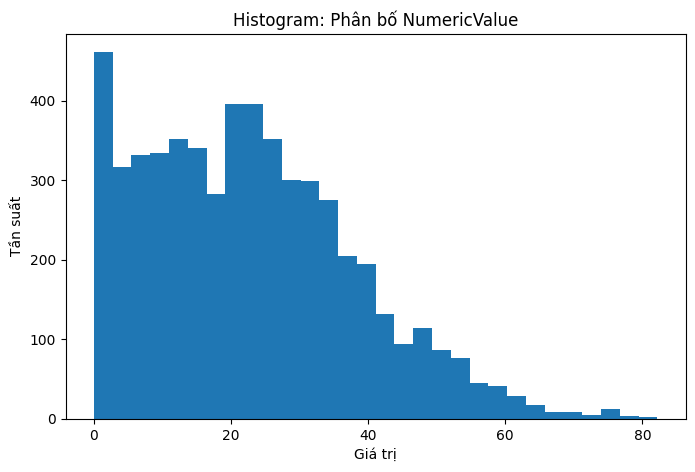

In [38]:
plt.figure(figsize=(8,5))
plt.hist(df["NumericValue"].dropna(), bins=30)
plt.title("Histogram: Phân bố NumericValue")
plt.xlabel("Giá trị")
plt.ylabel("Tần suất")
plt.show()

Text(0.5, 1.0, 'Boxplot: Phân bố NumericValue / IndicatorCode')

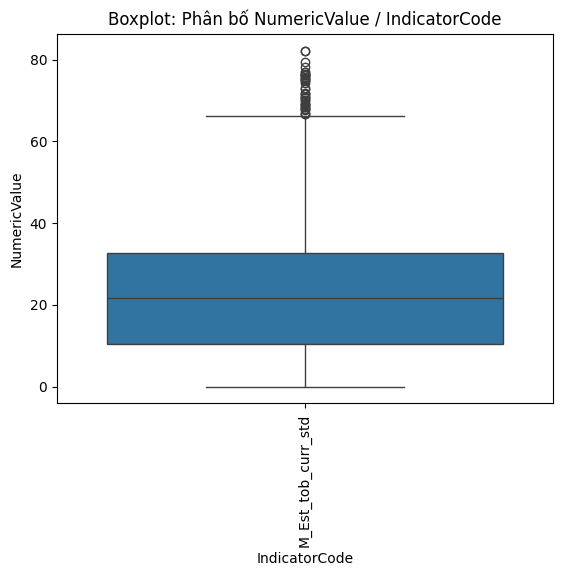

In [39]:
sns.boxplot(df, x = "IndicatorCode", y = "NumericValue")
plt.xticks(rotation=90);
plt.title("Boxplot: Phân bố NumericValue / IndicatorCode")

Text(0.5, 1.0, 'Boxplot: Phân bố NumericValue / IndicatorCode (Chuẩn hóa Log)')

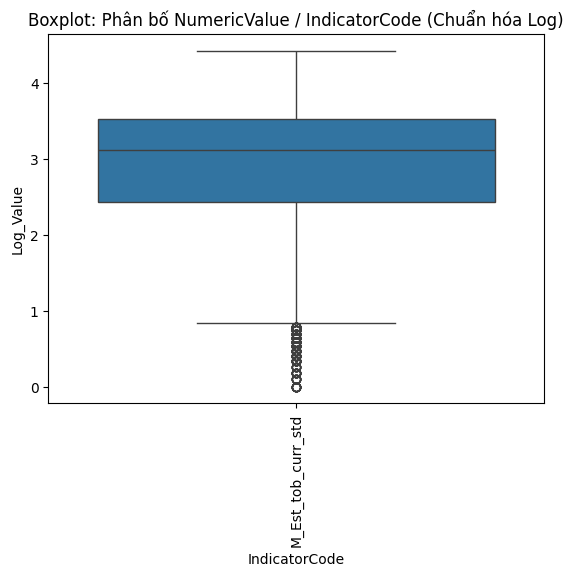

In [40]:
df['Log_Value'] = np.log1p(df['NumericValue'])
sns.boxplot(data=df, x="IndicatorCode", y="Log_Value")
plt.xticks(rotation=90);
plt.title("Boxplot: Phân bố NumericValue / IndicatorCode (Chuẩn hóa Log)")

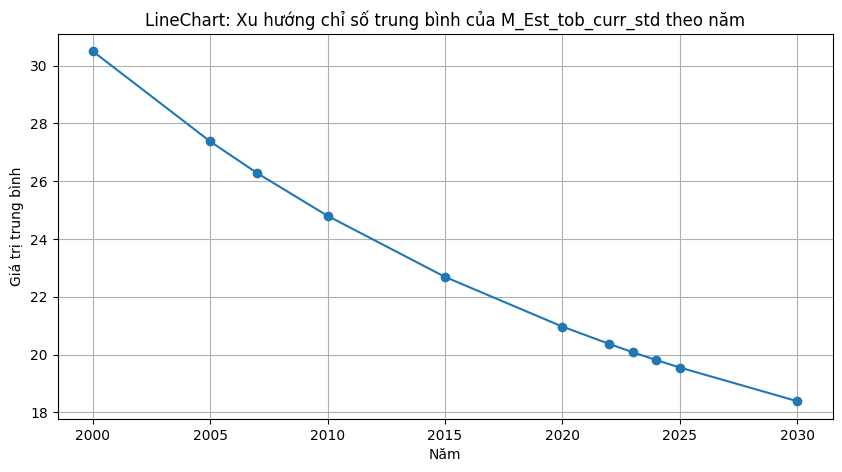

In [41]:
for indicator in list_IndicatorCode:
    df_indicator = df[df["IndicatorCode"] == indicator].reset_index(drop=True)
    df_year = (
    df_indicator.groupby("TimeDim")["NumericValue"]
    .mean()
    .reset_index()
    )
    plt.figure(figsize=(10,5))
    plt.plot(df_year["TimeDim"], df_year["NumericValue"], marker="o")
    plt.title(f"LineChart: Xu hướng chỉ số trung bình của {indicator} theo năm")
    plt.xlabel("Năm")
    plt.ylabel("Giá trị trung bình")
    plt.grid(True)
    plt.show()


In [42]:
# df_country = (
#     df.groupby("SpatialDim")["NumericValue"]
#     .mean()
#     .sort_values(ascending=False)
#     .head(10)
# )

# df_country.plot(kind="bar", figsize=(10,5))
# plt.title("BarChart: Top 10 quốc gia ô nhiễm cao nhất")
# plt.ylabel("Giá trị trung bình")
# plt.show()


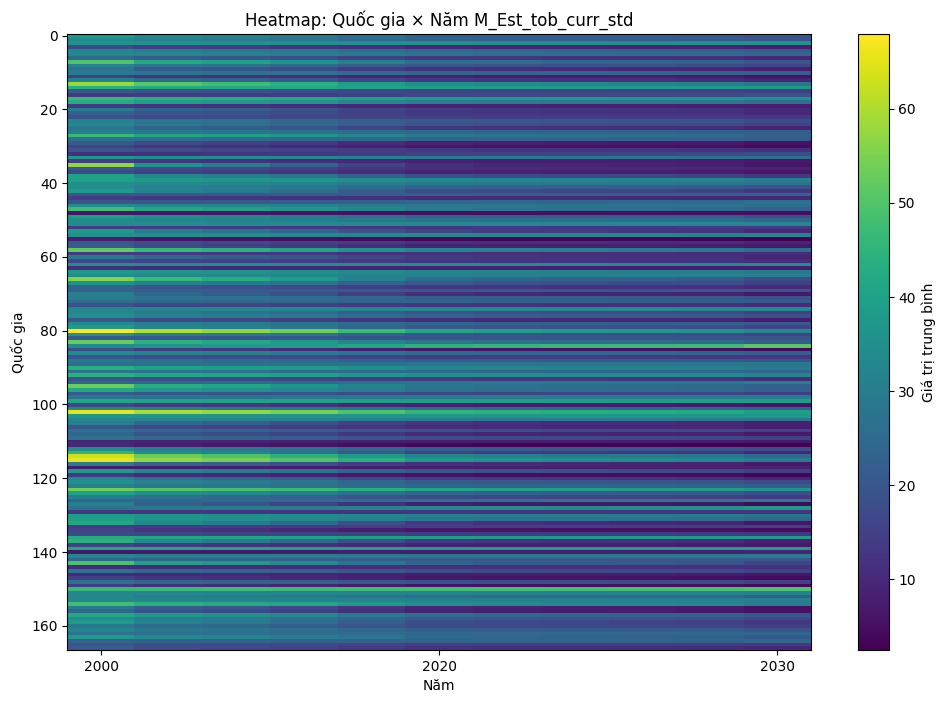

In [43]:
for indicator in list_IndicatorCode:
    df_indicator = df[df["IndicatorCode"] == indicator].reset_index(drop=True)
    pivot = df.pivot_table(
        index="SpatialDim",
        columns="TimeDim",
        values="NumericValue",
        aggfunc="mean"
    )

    plt.figure(figsize=(12,8))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label="Giá trị trung bình")
    plt.title(f"Heatmap: Quốc gia × Năm {indicator}")
    plt.xlabel("Năm")
    plt.ylabel("Quốc gia")
    step = 5
    plt.xticks(
    ticks=np.arange(0, len(pivot.columns), step),
    labels=pivot.columns[::step],
    )
    plt.show()


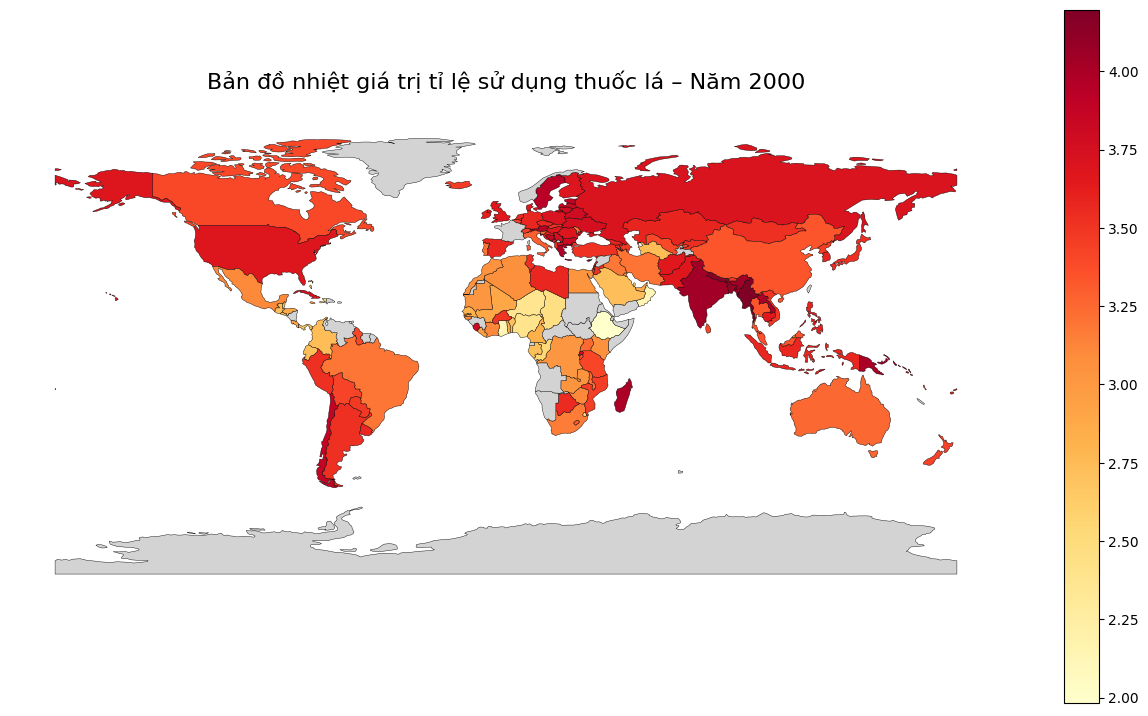

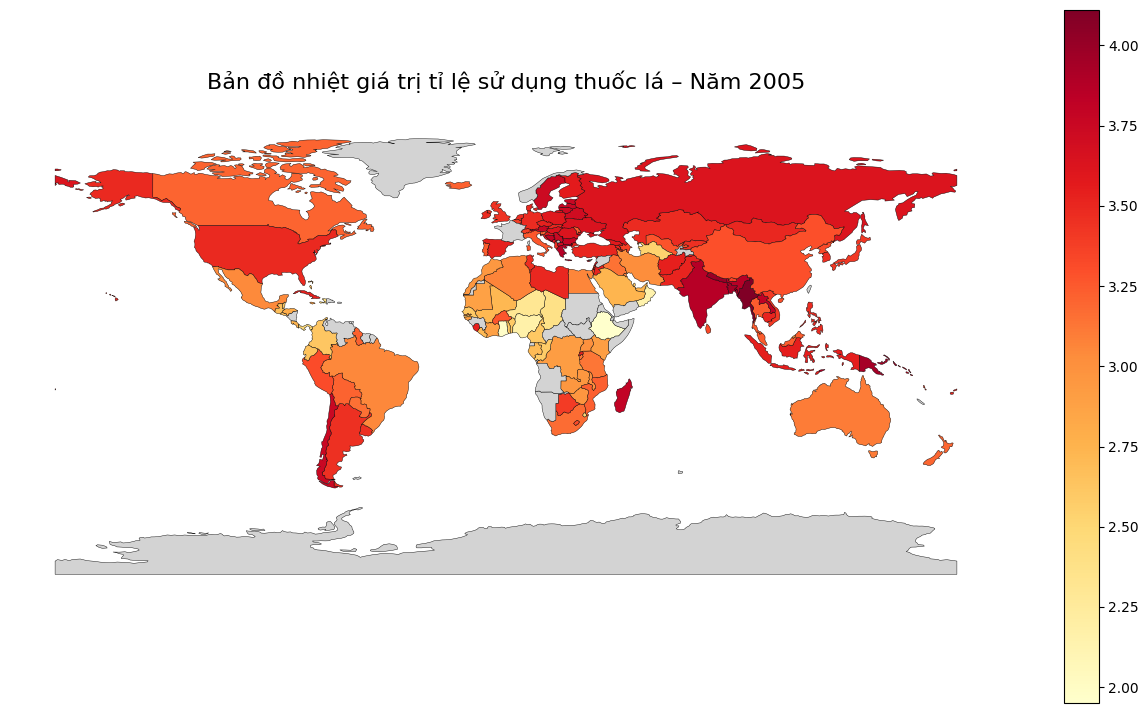

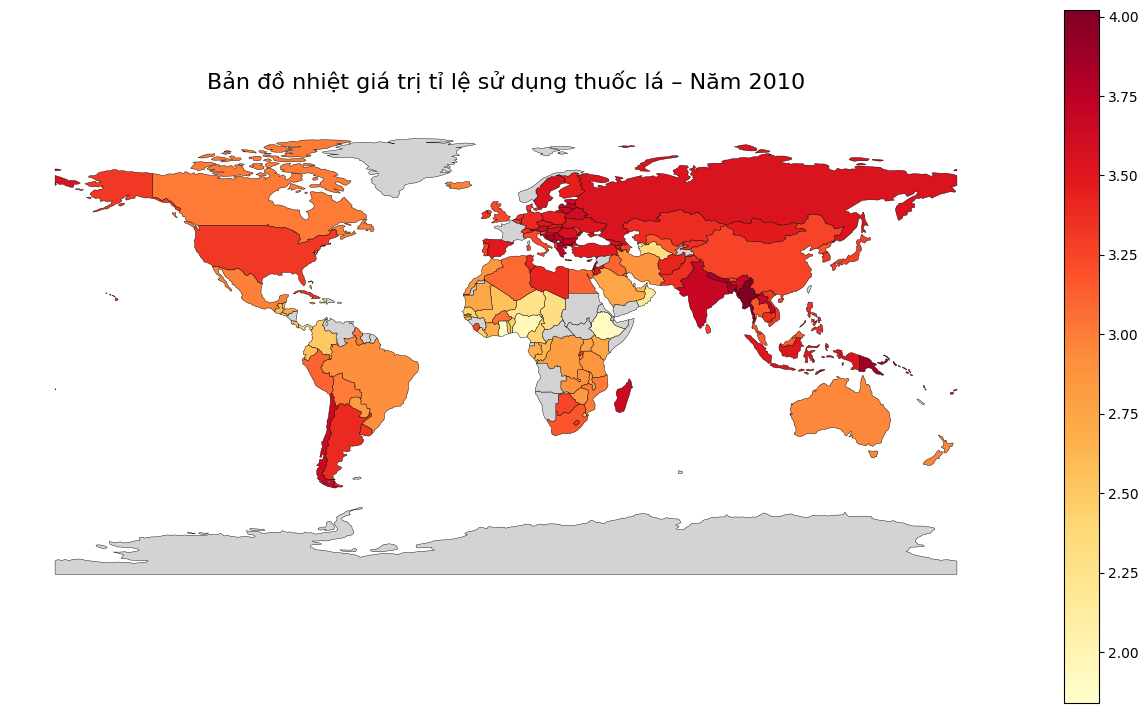

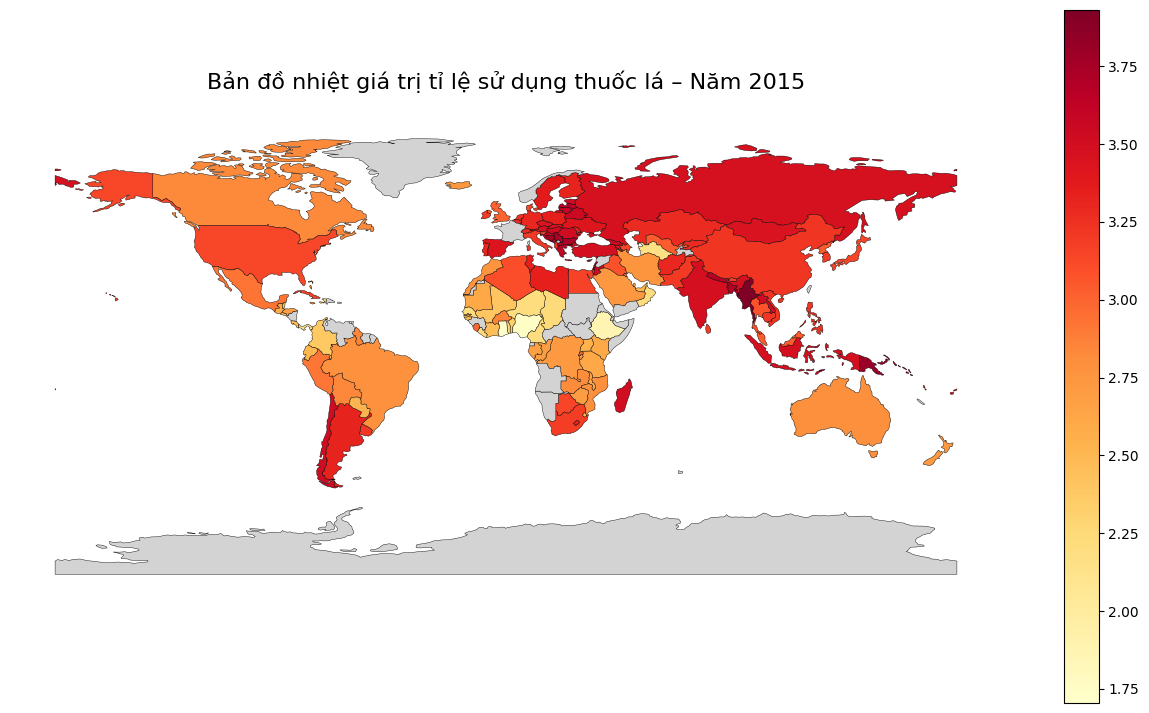

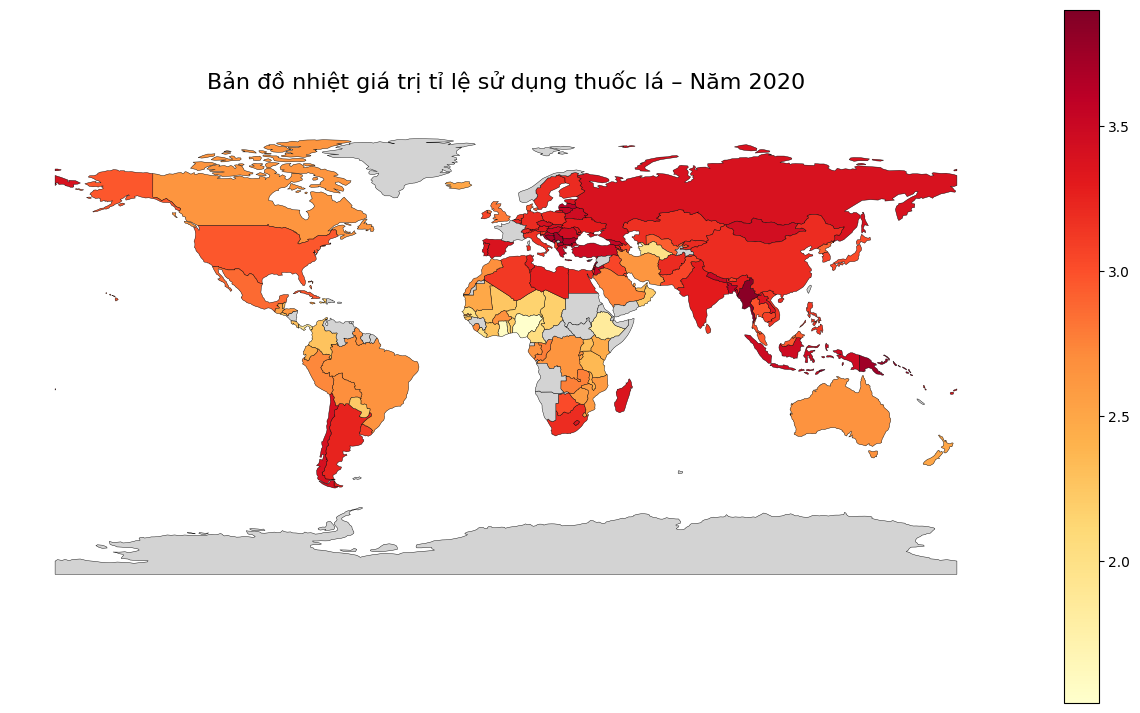

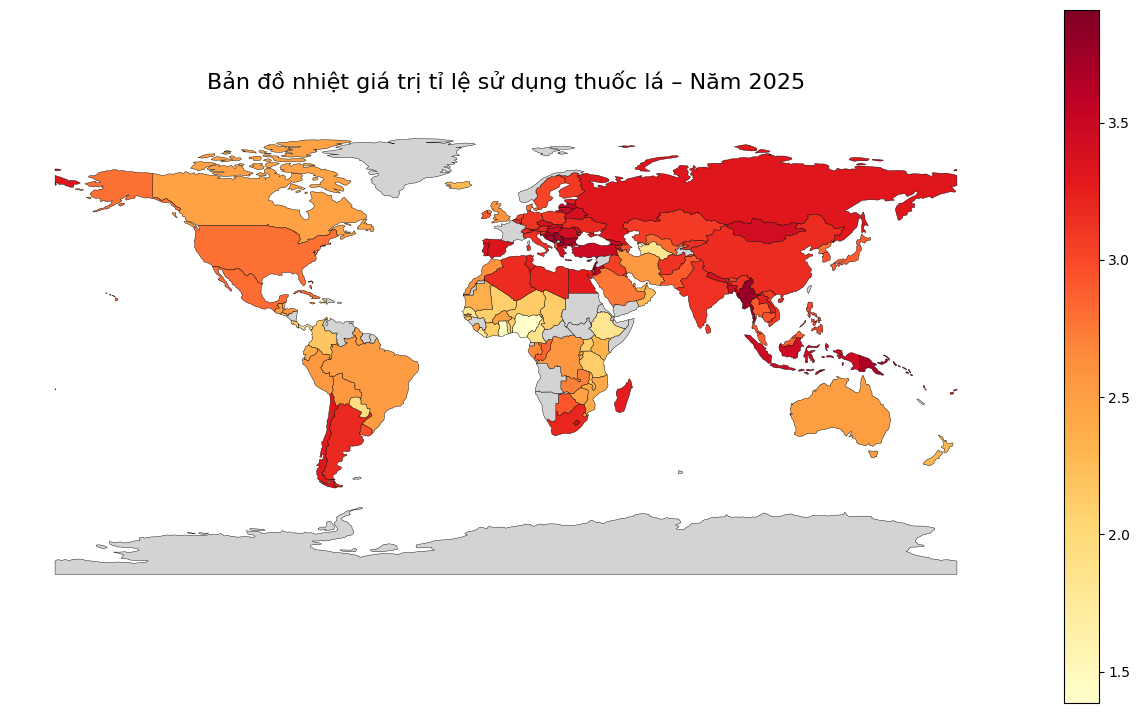

In [45]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np  

df["NumericValue"] = pd.to_numeric(df["NumericValue"], errors="coerce")

df_grouped = (
    df.groupby(
        ["SpatialDim", "ParentLocationCode", "TimeDim"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

for year in range(2000,2026,5):
    df_year = df_grouped[df_grouped["TimeDim"] == year]

    gdf = world.merge(
        df_year,
        how="left",
        left_on="ISO_A3",
        right_on="SpatialDim"
    )

    fig, ax = plt.subplots(figsize=(16, 9))

    gdf.plot(
        column="LogMeanValue",
        ax=ax,
        legend=True,
        cmap="YlOrRd",
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        }
    )

    ax.set_title(
        f"Bản đồ nhiệt giá trị tỉ lệ sử dụng thuốc lá – Năm {year}",
        fontsize=16,
        pad=20
    )

    ax.axis("off")
    plt.show()
